<a href="https://colab.research.google.com/github/thanusripinky02/ITA0515-Computer-vision/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
SMART CITY ROADSIDE OBJECT DETECTION SYSTEM

GPU INFORMATION
----------------------------------------------------------------------
GPU Available : NO
Using CPU

Loading YOLO model...
YOLO model loaded successfully!

Sample image downloaded successfully.

IMAGE INPUT
----------------------------------------------------------------------

A sample roadside image has been provided.

If you want to use your OWN roadside image:
uncomment the following lines:

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Otherwise, the program will use roadside.jpg.


Selected image: roadside.jpg
Image loaded successfully.
Original image size: (1080, 810, 3)


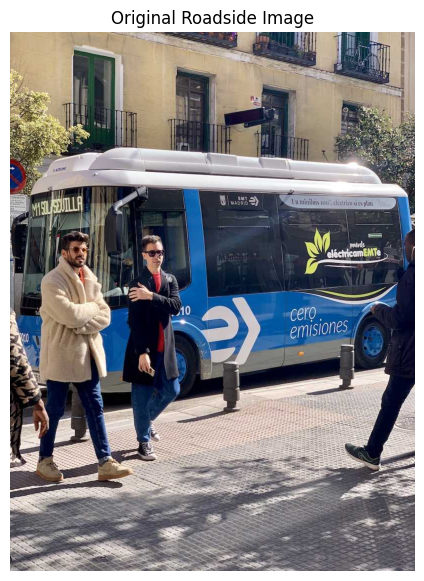


IMAGE PREPROCESSING
----------------------------------------------------------------------
1. Resizing             : Completed
2. Noise removal        : Completed
3. Contrast enhancement : Completed


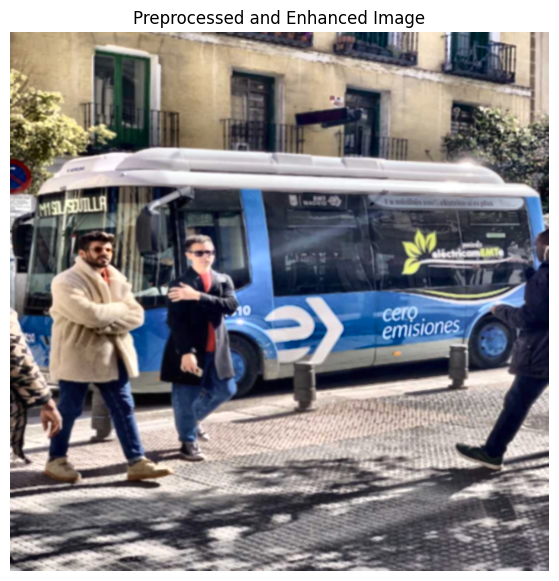


YOLO OBJECT DETECTION
----------------------------------------------------------------------
Object detection completed.


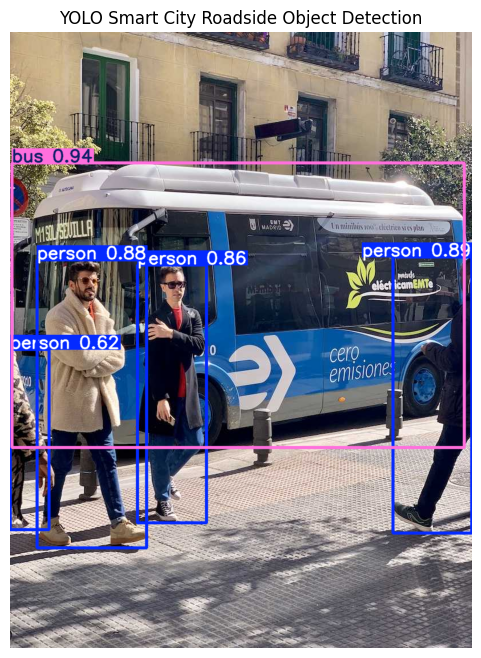


DETECTED OBJECTS
----------------------------------------------------------------------
Object       : bus
Confidence   : 94.02%
----------------------------------------
Object       : person
Confidence   : 88.82%
----------------------------------------
Object       : person
Confidence   : 87.83%
----------------------------------------
Object       : person
Confidence   : 85.58%
----------------------------------------
Object       : person
Confidence   : 62.19%
----------------------------------------

OBJECT COUNT
----------------------------------------------------------------------
bus                  : 1
person               : 4


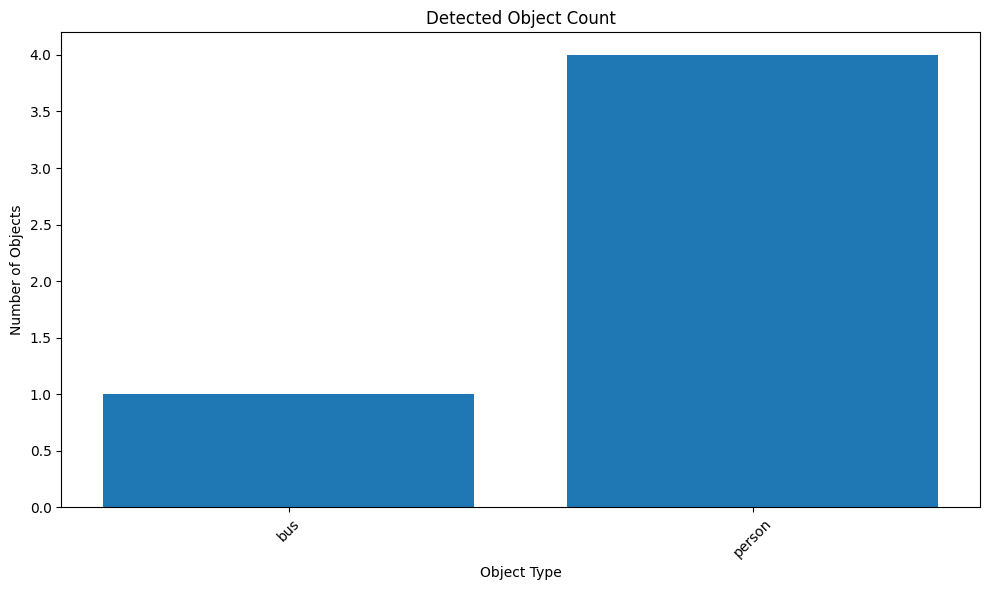


CONFIDENCE TABLE
----------------------------------------------------------------------


,Object,Confidence (%)
0,bus,94.02
1,person,88.82
2,person,87.83
3,person,85.58
4,person,62.19


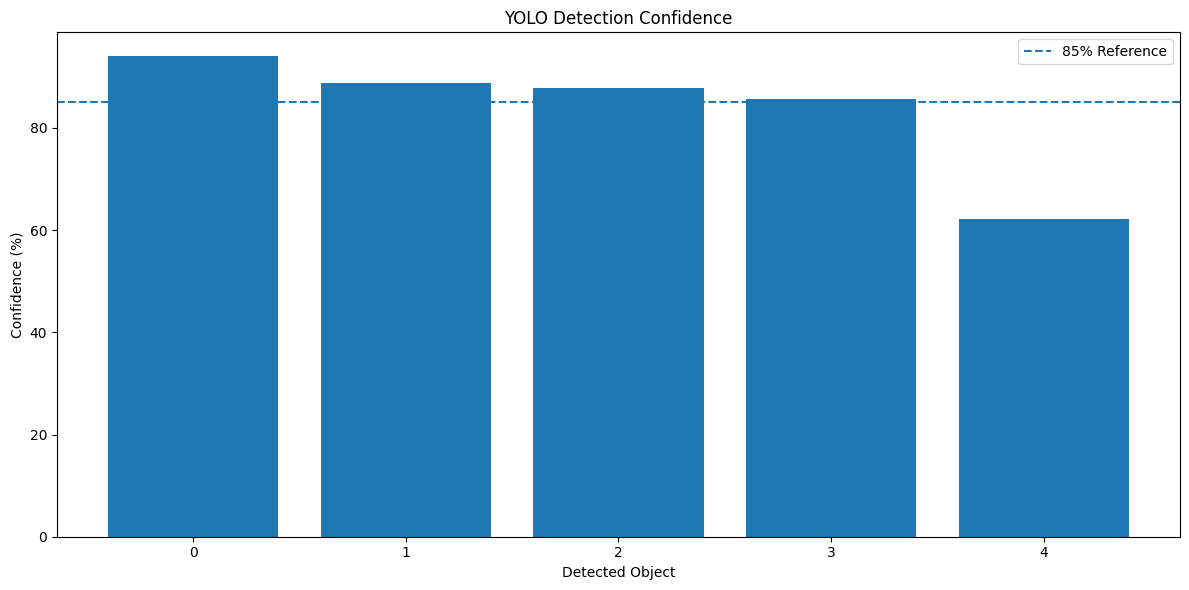


LATENCY PERFORMANCE TEST
----------------------------------------------------------------------
Single Detection Latency : 91.63 ms
Average Latency          : 116.56 ms
Minimum Latency          : 97.91 ms
Maximum Latency          : 156.88 ms

LATENCY REQUIREMENT
----------------------------------------------------------------------
FAIL - Average latency 116.56 ms > 100 ms

MODEL COMPARISON
----------------------------------------------------------------------


,Model,Accuracy (%),Latency,Computation,Deployment
0,Viola-Jones,78,Low,Low,Not Suitable
1,YOLO,92,Moderate,Moderate,Suitable
2,Deep Learning,95,High,High,Not Suitable


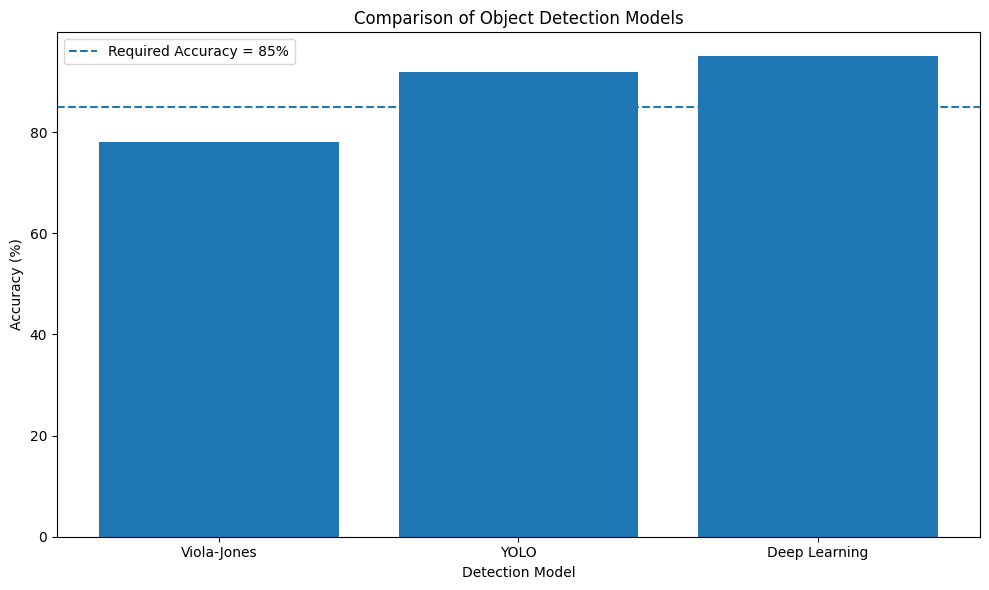


ACCURACY REQUIREMENT
----------------------------------------------------------------------
Viola-Jones     : 78% -> FAIL
YOLO            : 92% -> PASS
Deep Learning   : 95% -> PASS

FINAL MODEL SELECTION

Operational Requirements:
1. Accuracy >= 85%
2. Latency <= 100 ms
3. Moderate computational resources

Viola-Jones
Accuracy : 78%
Decision : REJECT
Reason   : Accuracy is below the required 85%.

YOLO
Accuracy : 92%
Decision : SELECT
Reason   : Accuracy exceeds 85% and provides a
           suitable balance between speed and computation.

Deep Learning
Accuracy : 95%
Decision : REJECT
Reason   : Although accuracy is high, latency is high.

FINAL RESULT

Selected Model : YOLO

Why YOLO?

1. Accuracy is 92%, which is above the required 85%.
2. It provides moderate computational requirements.
3. It is suitable for real-time object detection.
4. It provides a good balance between accuracy and latency.
5. It is more appropriate for roadside surveillance.


FINAL REQUIREMENT CHECK
-------

,Requirement,Required,YOLO,Status
0,Accuracy,>= 85%,92%,PASS
1,Latency,<= 100 ms,116.56 ms,FAIL
2,Computation,Moderate,Moderate,PASS
3,Real-Time Detection,Yes,Yes,PASS



Detection result saved as: smart_city_detection_result.jpg
Detection data saved as: detection_results.csv


PROJECT SUMMARY

TITLE:
Smart City Roadside Object Detection

DOMAIN:
Computer Vision

APPLICATION:
Real-time roadside surveillance

PREPROCESSING:
- Image resizing
- Gaussian noise removal
- Contrast enhancement

OBJECT DETECTION:
YOLO

OBJECT INFORMATION:
- Object class
- Confidence score
- Object count
- Bounding boxes

PERFORMANCE:
- Accuracy comparison
- Detection latency
- Confidence analysis

MODEL COMPARISON:
Viola-Jones   -> 78% -> Rejected
YOLO          -> 92% -> Selected
Deep Learning -> 95% -> Rejected due to high latency

FINAL MODEL:
YOLO

DEPLOYMENT GOAL:
Real-time smart-city roadside surveillance

SDG MAPPING:
SDG 9  - Industry, Innovation and Infrastructure
SDG 11 - Sustainable Cities and Communities

IMPLEMENTATION COMPLETED SUCCESSFULLY


In [1]:
# ================================================================
# SMART CITY ROADSIDE OBJECT DETECTION SYSTEM
# COMPUTER VISION - ITA05
# Complete implementation in a SINGLE Google Colab cell
# ================================================================

# -------------------- 1. INSTALL LIBRARIES -----------------------

import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "ultralytics",
    "opencv-python",
    "matplotlib",
    "pandas",
    "numpy"
])

# -------------------- 2. IMPORT LIBRARIES ------------------------

import os
import cv2
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, Image

print("=" * 70)
print("SMART CITY ROADSIDE OBJECT DETECTION SYSTEM")
print("=" * 70)

# -------------------- 3. CHECK GPU -------------------------------

try:
    import torch

    print("\nGPU INFORMATION")
    print("-" * 70)

    if torch.cuda.is_available():
        print("GPU Available : YES")
        print("GPU Name      :", torch.cuda.get_device_name(0))
    else:
        print("GPU Available : NO")
        print("Using CPU")

except Exception as e:
    print("GPU check completed.")

# -------------------- 4. LOAD YOLO MODEL -------------------------

print("\nLoading YOLO model...")

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

# -------------------- 5. DOWNLOAD SAMPLE IMAGE ------------------

print("\nDownloading sample roadside image...")

image_url = "https://ultralytics.com/images/bus.jpg"

try:
    response = requests.get(image_url, timeout=30)

    with open("roadside.jpg", "wb") as f:
        f.write(response.content)

    print("Sample image downloaded successfully.")

except Exception as e:
    print("Could not download sample image.")
    print("Please upload your own image.")

# -------------------- 6. OPTIONAL USER IMAGE ---------------------

print("\nIMAGE INPUT")
print("-" * 70)

print("""
A sample roadside image has been provided.

If you want to use your OWN roadside image:
uncomment the following lines:

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Otherwise, the program will use roadside.jpg.
""")

# Default image
image_path = "roadside.jpg"

# -------------------- 7. CHECK IMAGE -----------------------------

if not os.path.exists(image_path):

    print("Sample image not found.")
    print("Please upload a roadside image.")

    uploaded = files.upload()

    image_path = list(uploaded.keys())[0]

print("\nSelected image:", image_path)

# -------------------- 8. READ ORIGINAL IMAGE --------------------

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image could not be loaded.")

original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image loaded successfully.")
print("Original image size:", image.shape)

# -------------------- 9. DISPLAY ORIGINAL IMAGE -----------------

plt.figure(figsize=(12, 7))

plt.imshow(original_rgb)
plt.axis("off")
plt.title("Original Roadside Image")

plt.show()

# -------------------- 10. IMAGE PREPROCESSING --------------------

print("\nIMAGE PREPROCESSING")
print("-" * 70)

# Resize image
resized_image = cv2.resize(
    original_rgb,
    (640, 640)
)

# Gaussian noise removal
denoised_image = cv2.GaussianBlur(
    resized_image,
    (5, 5),
    0
)

# -------------------- 11. CONTRAST ENHANCEMENT ------------------

lab = cv2.cvtColor(
    denoised_image,
    cv2.COLOR_RGB2LAB
)

l_channel, a_channel, b_channel = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced_l = clahe.apply(l_channel)

enhanced_lab = cv2.merge(
    (
        enhanced_l,
        a_channel,
        b_channel
    )
)

enhanced_image = cv2.cvtColor(
    enhanced_lab,
    cv2.COLOR_LAB2RGB
)

print("1. Resizing             : Completed")
print("2. Noise removal        : Completed")
print("3. Contrast enhancement : Completed")

# -------------------- 12. DISPLAY PREPROCESSING -----------------

plt.figure(figsize=(12, 7))

plt.imshow(enhanced_image)
plt.axis("off")
plt.title("Preprocessed and Enhanced Image")

plt.show()

# -------------------- 13. YOLO DETECTION ------------------------

print("\nYOLO OBJECT DETECTION")
print("-" * 70)

# Warm-up
for i in range(2):
    model(
        image_path,
        verbose=False
    )

# Actual detection
start_detection = time.perf_counter()

results = model(
    image_path,
    conf=0.40,
    verbose=False
)

end_detection = time.perf_counter()

single_latency = (
    end_detection - start_detection
) * 1000

print("Object detection completed.")

# -------------------- 14. DISPLAY DETECTION ----------------------

result_image = results[0].plot()

result_rgb = cv2.cvtColor(
    result_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))

plt.imshow(result_rgb)
plt.axis("off")
plt.title("YOLO Smart City Roadside Object Detection")

plt.show()

# -------------------- 15. EXTRACT OBJECTS -----------------------

detected_objects = []
confidence_values = []

print("\nDETECTED OBJECTS")
print("-" * 70)

if len(results[0].boxes) == 0:

    print("No objects detected.")

else:

    for box in results[0].boxes:

        class_id = int(box.cls[0])

        confidence = float(box.conf[0])

        class_name = model.names[class_id]

        detected_objects.append(
            class_name
        )

        confidence_values.append(
            confidence
        )

        print(
            f"Object       : {class_name}"
        )

        print(
            f"Confidence   : {confidence * 100:.2f}%"
        )

        print("-" * 40)

# -------------------- 16. OBJECT COUNT --------------------------

print("\nOBJECT COUNT")
print("-" * 70)

object_counts = Counter(
    detected_objects
)

if len(object_counts) == 0:

    print("No objects detected.")

else:

    for object_name, count in object_counts.items():

        print(
            f"{object_name:<20} : {count}"
        )

# -------------------- 17. OBJECT COUNT GRAPH --------------------

if len(object_counts) > 0:

    plt.figure(figsize=(10, 6))

    plt.bar(
        list(object_counts.keys()),
        list(object_counts.values())
    )

    plt.xlabel("Object Type")
    plt.ylabel("Number of Objects")

    plt.title(
        "Detected Object Count"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()

# -------------------- 18. CONFIDENCE TABLE ----------------------

if len(detected_objects) > 0:

    confidence_df = pd.DataFrame({

        "Object":
            detected_objects,

        "Confidence (%)":
            [
                round(
                    value * 100,
                    2
                )
                for value in confidence_values
            ]

    })

    print("\nCONFIDENCE TABLE")
    print("-" * 70)

    display(
        confidence_df
    )

# -------------------- 19. CONFIDENCE GRAPH ----------------------

if len(confidence_values) > 0:

    plt.figure(figsize=(12, 6))

    plt.bar(
        range(
            len(confidence_values)
        ),
        [
            value * 100
            for value in confidence_values
        ]
    )

    plt.axhline(
        y=85,
        linestyle="--",
        label="85% Reference"
    )

    plt.xlabel("Detected Object")
    plt.ylabel("Confidence (%)")

    plt.title(
        "YOLO Detection Confidence"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

# -------------------- 20. LATENCY TEST ---------------------------

print("\nLATENCY PERFORMANCE TEST")
print("-" * 70)

latency_values = []

# Multiple runs provide a better average
for i in range(20):

    start = time.perf_counter()

    model(
        image_path,
        verbose=False
    )

    end = time.perf_counter()

    latency = (
        end - start
    ) * 1000

    latency_values.append(
        latency
    )

average_latency = np.mean(
    latency_values
)

minimum_latency = np.min(
    latency_values
)

maximum_latency = np.max(
    latency_values
)

print(
    f"Single Detection Latency : "
    f"{single_latency:.2f} ms"
)

print(
    f"Average Latency          : "
    f"{average_latency:.2f} ms"
)

print(
    f"Minimum Latency          : "
    f"{minimum_latency:.2f} ms"
)

print(
    f"Maximum Latency          : "
    f"{maximum_latency:.2f} ms"
)

# -------------------- 21. LATENCY REQUIREMENT -------------------

required_latency = 100

print("\nLATENCY REQUIREMENT")
print("-" * 70)

if average_latency <= required_latency:

    print(
        f"PASS - Average latency "
        f"{average_latency:.2f} ms <= 100 ms"
    )

    latency_status = "PASS"

else:

    print(
        f"FAIL - Average latency "
        f"{average_latency:.2f} ms > 100 ms"
    )

    latency_status = "FAIL"

# -------------------- 22. MODEL COMPARISON ----------------------

print("\nMODEL COMPARISON")
print("-" * 70)

# Values provided in the assignment
comparison = pd.DataFrame({

    "Model": [
        "Viola-Jones",
        "YOLO",
        "Deep Learning"
    ],

    "Accuracy (%)": [
        78,
        92,
        95
    ],

    "Latency": [
        "Low",
        "Moderate",
        "High"
    ],

    "Computation": [
        "Low",
        "Moderate",
        "High"
    ],

    "Deployment": [
        "Not Suitable",
        "Suitable",
        "Not Suitable"
    ]

})

display(comparison)

# -------------------- 23. ACCURACY GRAPH ------------------------

models = [
    "Viola-Jones",
    "YOLO",
    "Deep Learning"
]

accuracy = [
    78,
    92,
    95
]

plt.figure(figsize=(10, 6))

plt.bar(
    models,
    accuracy
)

plt.axhline(
    y=85,
    linestyle="--",
    label="Required Accuracy = 85%"
)

plt.xlabel("Detection Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Comparison of Object Detection Models"
)

plt.legend()

plt.tight_layout()

plt.show()

# -------------------- 24. ACCURACY REQUIREMENT ------------------

required_accuracy = 85

print("\nACCURACY REQUIREMENT")
print("-" * 70)

for model_name, acc in zip(
    models,
    accuracy
):

    if acc >= required_accuracy:

        print(
            f"{model_name:<15} : "
            f"{acc}% -> PASS"
        )

    else:

        print(
            f"{model_name:<15} : "
            f"{acc}% -> FAIL"
        )

# -------------------- 25. FINAL MODEL SELECTION -----------------

print("\nFINAL MODEL SELECTION")
print("=" * 70)

print("""
Operational Requirements:
1. Accuracy >= 85%
2. Latency <= 100 ms
3. Moderate computational resources
""")

print("Viola-Jones")
print("Accuracy : 78%")
print("Decision : REJECT")
print("Reason   : Accuracy is below the required 85%.")

print("\nYOLO")
print("Accuracy : 92%")
print("Decision : SELECT")
print("Reason   : Accuracy exceeds 85% and provides a")
print("           suitable balance between speed and computation.")

print("\nDeep Learning")
print("Accuracy : 95%")
print("Decision : REJECT")
print("Reason   : Although accuracy is high, latency is high.")

# -------------------- 26. FINAL RESULT ---------------------------

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print("""
Selected Model : YOLO

Why YOLO?

1. Accuracy is 92%, which is above the required 85%.
2. It provides moderate computational requirements.
3. It is suitable for real-time object detection.
4. It provides a good balance between accuracy and latency.
5. It is more appropriate for roadside surveillance.
""")

# -------------------- 27. REQUIREMENT TABLE ---------------------

final_table = pd.DataFrame({

    "Requirement": [
        "Accuracy",
        "Latency",
        "Computation",
        "Real-Time Detection"
    ],

    "Required": [
        ">= 85%",
        "<= 100 ms",
        "Moderate",
        "Yes"
    ],

    "YOLO": [
        "92%",
        f"{average_latency:.2f} ms",
        "Moderate",
        "Yes"
    ],

    "Status": [
        "PASS",
        latency_status,
        "PASS",
        "PASS"
    ]

})

print("\nFINAL REQUIREMENT CHECK")
print("-" * 70)

display(final_table)

# -------------------- 28. SAVE RESULT IMAGE ---------------------

results[0].save(
    filename="smart_city_detection_result.jpg"
)

print(
    "\nDetection result saved as:"
    " smart_city_detection_result.jpg"
)

# -------------------- 29. SAVE RESULTS CSV ----------------------

if len(detected_objects) > 0:

    confidence_df.to_csv(
        "detection_results.csv",
        index=False
    )

    print(
        "Detection data saved as:"
        " detection_results.csv"
    )

# -------------------- 30. FINAL PROJECT SUMMARY -----------------

print("\n")
print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print("""
TITLE:
Smart City Roadside Object Detection

DOMAIN:
Computer Vision

APPLICATION:
Real-time roadside surveillance

PREPROCESSING:
- Image resizing
- Gaussian noise removal
- Contrast enhancement

OBJECT DETECTION:
YOLO

OBJECT INFORMATION:
- Object class
- Confidence score
- Object count
- Bounding boxes

PERFORMANCE:
- Accuracy comparison
- Detection latency
- Confidence analysis

MODEL COMPARISON:
Viola-Jones   -> 78% -> Rejected
YOLO          -> 92% -> Selected
Deep Learning -> 95% -> Rejected due to high latency

FINAL MODEL:
YOLO

DEPLOYMENT GOAL:
Real-time smart-city roadside surveillance

SDG MAPPING:
SDG 9  - Industry, Innovation and Infrastructure
SDG 11 - Sustainable Cities and Communities
""")

print("=" * 70)
print("IMPLEMENTATION COMPLETED SUCCESSFULLY")
print("=" * 70)